<a href="https://colab.research.google.com/github/siddmohanty111/PlaylistClustering/blob/main/Math_250_Spotify_tSNE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import sys
# import importlib
# from google.colab import drive
# drive.mount('/content/drive')

# !git clone https://github.com/siddmohanty111/PlaylistClustering.git
# !git pull

# %cd /content/PlaylistClustering
# !pip install -r requirements.txt
# !pip install sentence-transformers

Mounted at /content/drive
Cloning into 'PlaylistClustering'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 33 (delta 14), reused 22 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 18.11 KiB | 18.11 MiB/s, done.
Resolving deltas: 100% (14/14), done.
fatal: not a git repository (or any of the parent directories): .git
/content/PlaylistClustering
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.8/478.8 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully unins

In [2]:
# !PYTHONPATH=/content/PlaylistClustering:$PYTHONPATH
# !python firsttimesetup.py

--- Starting JSON to CSV Conversion ---
Attempt 1/5 to convert JSON to CSV...
Lecture du fichier mpd.slice.0-999.json...
Lecture du fichier mpd.slice.1000-1999.json...
Lecture du fichier mpd.slice.10000-10999.json...
Lecture du fichier mpd.slice.100000-100999.json...
Lecture du fichier mpd.slice.101000-101999.json...
Lecture du fichier mpd.slice.102000-102999.json...
Lecture du fichier mpd.slice.103000-103999.json...
Lecture du fichier mpd.slice.104000-104999.json...
Lecture du fichier mpd.slice.105000-105999.json...
Lecture du fichier mpd.slice.106000-106999.json...
Lecture du fichier mpd.slice.107000-107999.json...
Lecture du fichier mpd.slice.108000-108999.json...
Lecture du fichier mpd.slice.109000-109999.json...
Lecture du fichier mpd.slice.11000-11999.json...
Lecture du fichier mpd.slice.110000-110999.json...
Lecture du fichier mpd.slice.111000-111999.json...
Lecture du fichier mpd.slice.112000-112999.json...
Lecture du fichier mpd.slice.113000-113999.json...
Lecture du fichier m

In [1]:
import pickle

# Path to the embeddings
embed_path = '/content/drive/MyDrive/Spotify Playlist Data/Processed Data/calced_embeddings/playlists_embeddings_sbert.pkl'

with open(embed_path, 'rb') as f:
    embeddings = pickle.load(f)

# Instead of .shape, let's see what the labels are
print(f"The dictionary keys are: {embeddings.keys()}")

# If you want to see how many items are in it
print(f"Number of entries: {len(embeddings)}")

The dictionary keys are: dict_keys(['playlist_embeddings', 'playlist_titles', 'playlist_tracks'])
Number of entries: 3


In [2]:
import numpy as np
raw_data = embeddings['playlist_embeddings'] # or whatever the key is chosen

# Take a sample of XXXX to keep Colab from crashing
sample_size = 10000
sample_data = raw_data[:sample_size]

# Convert to a clean NumPy array
data_matrix = np.array(sample_data, dtype=np.float32)

print(f"Success! Data matrix shape: {data_matrix.shape}")

Success! Data matrix shape: (10000, 384)


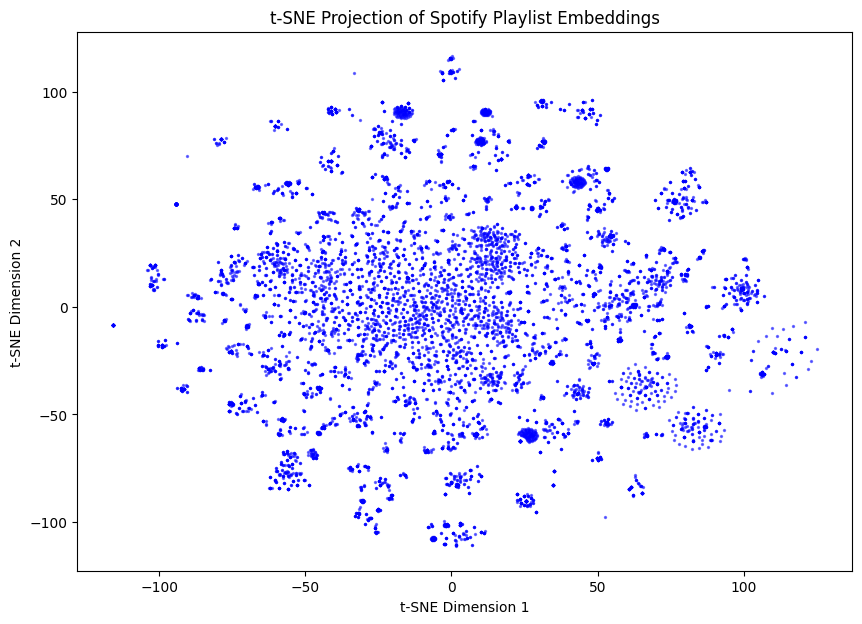

In [3]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Reduce dimensions to 50 using PCA (standard pre-processing for t-SNE)
pca = PCA(n_components=50)
data_pca = pca.fit_transform(data_matrix)

# 2. Run t-SNE on the PCA results
tsne = TSNE(n_components=2, perplexity=30, initialization='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(data_pca)

# 3. Plot
plt.scatter(vis_dims[:, 0], vis_dims[:, 1], s=2, alpha=0.5)
plt.title("t-SNE of Playlist Embeddings (Sample)")
plt.show()

In [4]:
# Create a list of IDs in the exact order they appear in the matrix
pids = list(embeddings.keys())

# Now can use these IDs to look up names in playlists_df later

Sample shape: (20000, 384)
t-SNE complete.


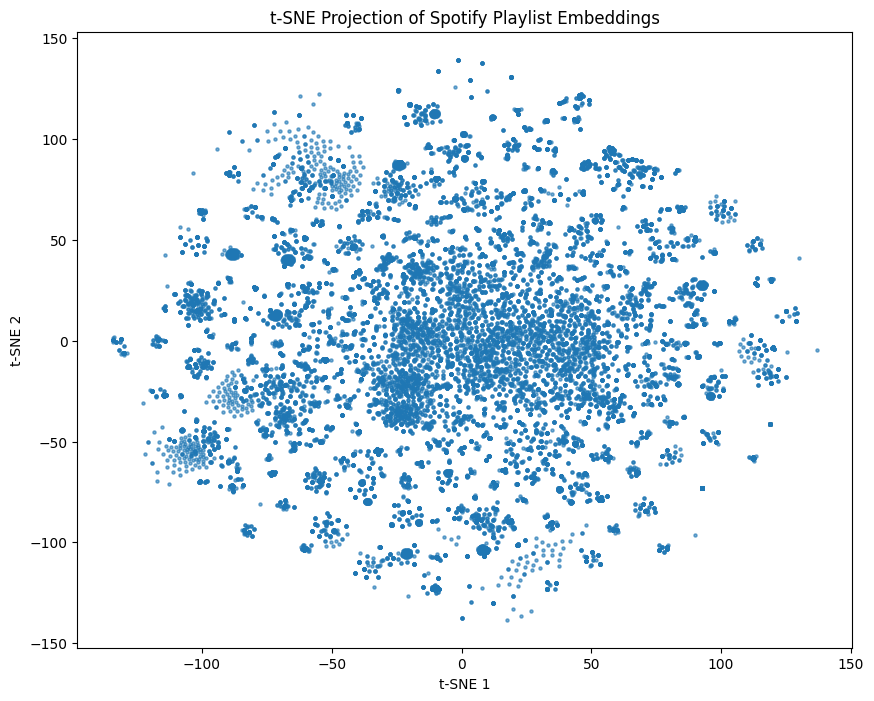

In [5]:
# Consolidated code

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load embeddings
raw_data = np.array(embeddings["playlist_embeddings"], dtype=np.float32)

# Random sample for t-SNE
sample_size = 20000
rng = np.random.default_rng(42)
idx = rng.choice(len(raw_data), size=sample_size, replace=False)
sample_matrix = raw_data[idx]

print("Sample shape:", sample_matrix.shape)

# PCA preprocessing
pca = PCA(n_components=50, random_state=42)
sample_pca = pca.fit_transform(sample_matrix)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=42
)

embeddings_2d = tsne.fit_transform(sample_pca)
print("t-SNE complete.")

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.6)
plt.title("t-SNE Projection of Spotify Playlist Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [10]:
np.savez(
    "tsne_results.npz",
    embeddings_2d=embeddings_2d,
    sample_indices=idx
)

In [9]:
data = np.load("tsne_results.npz")

embeddings_2d = data["embeddings_2d"]
idx = data["sample_indices"]

In [11]:
# import os

# if os.path.exists("data/tsne_results.npz"):
#     print("Loading existing t-SNE results...")
#     data = np.load("data/tsne_results.npz")
#     embeddings_2d = data["embeddings_2d"]
# else:
#     print("Running t-SNE...")
#     embeddings_2d = tsne.fit_transform(sample_pca)

#     np.savez(
#         "data/tsne_results.npz",
#         embeddings_2d=embeddings_2d,
#         sample_indices=idx
#     )

Running t-SNE...


FileNotFoundError: [Errno 2] No such file or directory: 'data/tsne_results.npz'

In [12]:
# import joblib
# joblib.dump(pca, "data/pca_model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'data/pca_model.pkl'

In [ ]:
# pca = joblib.load("data/pca_model.pkl")